# Needle-in-a-haystack latency sweep

Tests each model in `MODELS`' **retrieval accuracy and serving latency as a function of context-window length**. A custom "needle" fact that no public model could know (default: a fake birthday) is inserted at a fixed depth (middle) inside a haystack built from concatenated TriviaQA Q/A pairs, and we ask the model to retrieve it. For each (model, context length) we record:

- **Needle-retrieval accuracy** — did the model actually find the fact? (a single correct answer proves it read the haystack; no contamination leak)
- **Latency** — p50 / p95 / mean wall-clock per request, which grows with input length as prefill work scales
- **Throughput** — decode tok/s and prefill tok/s, measured with **streaming** so we can split latency into TTFT (prefill) and decode. Decode tok/s = `out_tokens / (latency - TTFT)` **excludes prefill** — the Artificial Analysis [Output Speed](https://artificialanalysis.ai/methodology/performance-benchmarking) definition — reported as median (sustained) and peak (fastest rep). Prefill tok/s = `prompt_tokens / latency` is the haystack ingest rate.

This is a *context-length* sweep, not a concurrency sweep (see `throughput_load_sweep.ipynb` for that). Requests run sequentially at concurrency 1 so latency is clean and not muddied by queueing.

**Prereqs:** API keys for whichever providers you enable in `MODELS` — `FIREWORKS_API_KEY`, `OPENROUTER_API_KEY`, `TOGETHER_API_KEY`, `BASETEN_API_KEY` (only the ones you select are required) in `training/.env` or your shell. TriviaQA `unfiltered.nocontext` (~600MB Q&A-only split, no auth) is loaded via `datasets` and cached thereafter.

> Cost warning: this sweeps up to GLM-5.2's full **1M-token context window**. The largest runs are slow (each 1M-token prefill can take minutes) and expensive (~$1.40 per 1M input tokens on Fireworks serverless, x `NUM_REPS`). A full sweep with `NUM_REPS=5` across all 7 lengths is on the order of $20+. Comment out the big entries in `CONTEXT_LENGTHS` (262144 / 524288 / 1048576) for a cheap smoke test first.

## How this experiment works

### The setup

We want to know two things about each model as the input gets long:
1. **Does it still find a specific fact buried in a wall of text?** (retrieval accuracy)
2. **How does serving latency / throughput scale with input length?** (prefill cost, decode speed)

To test (1) fairly, we need a fact the model could *not* already know from training — otherwise a correct answer might just be memorization, not evidence it read the haystack. So we use a **private needle**: a made-up fact like "The author's secret birthday is March 14, 1991" that no public model has seen. The only way to answer correctly is to actually read it out of the context.

### The haystack

We build a long prompt by concatenating real **TriviaQA question/answer pairs** ("Q: ...\nA: ...\n") until the input reaches a target token count. This is the *haystack*. Then we splice the needle fact in at the **middle** of the haystack (50% by character position) and end the prompt with a question asking for the needle:

```
Q: <trivia question 1>
A: <answer 1>
Q: <trivia question 2>
A: <answer 2>
...
The author's secret birthday is March 14, 1991.   <-- the needle, spliced in the middle
...
Q: <trivia question N>
A: <answer N>

What is the author's secret birthday? Answer with just the date as written in the fact.
```

We sweep the **total input length** across a range of targets (e.g. 2K → 262K tokens) to see how both retrieval and latency change as the haystack grows.

### Defeating prefix caching (why every rep is different)

Inference servers cache long shared prefixes across requests. If we sent the same haystack 5 times, requests 2–5 would skip prefill and look artificially fast. So each repetition ("rep") uses:
- a **different needle** (rotated through a pool of 8 private facts), and
- a **differently shuffled** order of the TriviaQA filler.

No two reps share a byte prefix, so every rep pays full prefill. Grading is per-rep (each rep is checked against its own needle's answer).

### The metrics

Each request is **streamed**, which lets us split its wall time into two phases:

| metric | what it is | what it tells you |
|---|---|---|
| **TTFT** (time to first token) | seconds from send → first content chunk | **prefill** cost — ingesting + processing the haystack before decoding starts. Rises with input length. |
| **latency** | total wall time (send → final chunk) | prefill + decode combined |
| **dec t/s** (decode tok/s) | `out_tokens / (latency - TTFT)` — **prefill excluded** | the Artificial Analysis [Output Speed](https://artificialanalysis.ai/methodology/performance-benchmarking) metric: how fast the model *generates*, isolated from prefill. Should stay flat as context grows; a drop means decode itself is slowing under long-context KV pressure. |
| **prefill tok/s** | `prompt_tokens / latency` | how fast the server **ingests** the haystack. Roughly flat = steady ingest rate; dropping at large ctx = a serving throughput ceiling. |
| **accuracy** | fraction of reps where the needle answer appeared in the output | did the model find the fact? A drop at large context = "lost in the middle." |

**dec med** = median decode tok/s across the reps at that context length (the sustained, trustworthy number). **peak** = the fastest single rep.

> ⚠️ **Peak is noisy for short responses.** `dec t/s = out_tokens / (latency - TTFT)` divides by the wall-clock decode window. If a response emits only a few tokens, or arrives in one batched chunk, that window can be ~0.03s and `dec t/s` explodes to hundreds/thousands — that measures network/chunk batching, not sustained generation. **Treat `dec med` as the headline; treat `peak` as a best-case ceiling that's only meaningful when the response was long enough to span many chunks.**

### How to read the results

- **Accuracy curve dropping as context grows** → the model is "lost in the middle": it stops finding the needle once the haystack is big. A flat 100% line means retrieval holds up across the whole window.
- **TTFT climbing with input length** → expected, prefill work scales with input. If TTFT dominates total latency at large ctx, the request is **prefill-bound**.
- **decode tok/s roughly flat** → the model decodes at a constant rate regardless of input size. Dropping → decode is slowing (KV-cache pressure, long-context attention cost).
- **prefill tok/s roughly flat** → the server ingests context at a steady rate. Dropping at large ctx → a serving throughput ceiling (memory bandwidth / KV-cache capacity).

### Comparing to the throughput notebook

This notebook sweeps **context length** at concurrency 1 (clean per-request latency, no queueing). The sibling `throughput_load_sweep.ipynb` sweeps **concurrency** at a fixed short context (how does the server scale under load). Together they answer: "how does the model handle *long* inputs?" (this notebook) vs "how does the server handle *many* inputs at once?" (the throughput notebook).

In [1]:
# Run once if imports fail (uses the notebook kernel's Python).
import sys
!{sys.executable} -m pip install -q -e "../../.[eval]" matplotlib datasets

In [2]:
# --- edit these: one row per model = (litellm id, reasoning extra_body, api_base, api_key_env) ---
# Same model set as throughput_load_sweep.ipynb. extra_body is forwarded verbatim
# (bypasses litellm's per-provider param validation). Fireworks/Together/Baseten take
# top-level reasoning_effort; OpenRouter takes reasoning:{...} (Opus needs enabled:True).
MODELS_CFG = {
    "GLM-5.2 FAST (Fireworks)": ("fireworks_ai/accounts/fireworks/routers/glm-5p2-fast", {"reasoning_effort": "max"}, None, None),
    "GLM-5.2 (Anonymous 1)":    ("together_ai/zai-org/GLM-5.2",                           {"reasoning_effort": "max"}, None, None),
    "GLM-5.2 (Anonymous 2)":    ("openai/zai-org/GLM-5.2", {"reasoning_effort": "max"}, "https://inference.baseten.co/v1", "BASETEN_API_KEY"),
    "GPT-5.5 (OpenRouter)":     ("openrouter/openai/gpt-5.5",             {"reasoning": {"effort": "xhigh"}},                None, None),
    "Opus 4.8 (OpenRouter)":    ("openrouter/anthropic/claude-opus-4.8",  {"reasoning": {"effort": "max", "enabled": True}}, None, None),
    "Kimi K3 (Fireworks)":      ("fireworks_ai/accounts/fireworks/models/kimi-k3",        {"reasoning_effort": "max"}, None, None),
    # "GLM-5.2 (Fireworks)":   ("fireworks_ai/accounts/fireworks/models/glm-5p2",        {"reasoning_effort": "max"}, None, None),
}
REASONING_EFFORT = "max"   # set "" to disable reasoning and use each provider's default
MODELS         = {k: v[0] for k, v in MODELS_CFG.items()}
_REASONING_FOR = {v[0]: v[1] for v in MODELS_CFG.values()}
_API_BASE_FOR  = {v[0]: v[2] for v in MODELS_CFG.values() if v[2]}
_API_KEY_FOR   = {v[0]: v[3] for v in MODELS_CFG.values() if v[3]}

# The sweep axis: target input-token counts for the haystack.
# GLM-5.2 on Fireworks supports a 1,048,576-token (1M) context window, so the
# top of this range is the model's true max. A 1M-token prefill is slow and
# expensive (~$1.40/1M input tokens at serverless rates, x NUM_REPS), so the
# default goes to 1M but you can comment out the big ones for a smoke test.
CONTEXT_LENGTHS = [2_048, 4_096]
# CONTEXT_LENGTHS = [2_048, 4_096, 16_384, 32_768, 65_536, 131_072]
# CONTEXT_LENGTHS = [2048, 4096, 16384, 65536, 131072, 262144, 524288, 1048576]

# The needle. Edit NEEDLE_FACT / NEEDLE_QUESTION / NEEDLE_ANSWER to your own
# private fact so a correct answer can only come from reading the haystack.
NEEDLE_FACT = "The author's secret birthday is March 14, 1991."
NEEDLE_QUESTION = "What is the author's secret birthday? Answer with just the date as written in the fact."
NEEDLE_ANSWER = "March 14, 1991"   # ground truth for grading

# Pool of distinct needle facts. Each rep uses a different one (cycled) so the
# model can't memoize a single answer, and grading is per-rep correct. Each rep
# also gets a freshly shuffled haystack, so no two reps share a prefix and the
# server can't shortcut via prefix caching. Add your own private facts here.
NEEDLE_POOL = [
    {"fact": "The author's secret birthday is March 14, 1991.",
     "question": "What is the author's secret birthday? Answer with just the date as written in the fact.",
     "answer": "March 14, 1991"},
    {"fact": "The author's favorite hidden number is 4193.",
     "question": "What is the author's favorite hidden number? Answer with just the number as written in the fact.",
     "answer": "4193"},
    {"fact": "The author's secret codename is Blue Otter.",
     "question": "What is the author's secret codename? Answer with just the codename as written in the fact.",
     "answer": "Blue Otter"},
    {"fact": "The author's secret passcode is 7-2-9-1.",
     "question": "What is the author's secret passcode? Answer with just the digits separated by dashes as written in the fact.",
     "answer": "7-2-9-1"},
    {"fact": "The author's hidden city is Reykjavik.",
     "question": "What is the author's hidden city? Answer with just the city name as written in the fact.",
     "answer": "Reykjavik"},
    {"fact": "The author's secret pet's name is Mochi.",
     "question": "What is the author's secret pet's name? Answer with just the name as written in the fact.",
     "answer": "Mochi"},
    {"fact": "The author's favorite secret color is vermillion.",
     "question": "What is the author's favorite secret color? Answer with just the color as written in the fact.",
     "answer": "vermillion"},
    {"fact": "The author's secret mountain is Denali.",
     "question": "What is the author's secret mountain? Answer with just the mountain name as written in the fact.",
     "answer": "Denali"},
]

# Where in the haystack (by character fraction) the needle is spliced in.
# 0.5 = middle. Fixed here; context length is the only swept axis.
NEEDLE_DEPTH_FRAC = 0.5

NUM_REPS = 5            # sequential requests per context length (clean latency)
# Budget for the *visible* answer (we just want the date back, ~3-6 tokens)
# PLUS the model's hidden reasoning tokens. At reasoning_effort=max the
# model thinks a lot before answering, and thinking tokens count against
# this budget -- so 128 is too tight and most reps emit 0 visible tokens
# (stream closes mid-reasoning). 1024 leaves comfortable headroom; the
# final answer is still tiny so decode time stays short.
MAX_TOKENS = 1024
REQUEST_TIMEOUT_S = 600   # 1M-token prefills can take several minutes

# TriviaQA config used as filler. `unfiltered.nocontext` is Q&A pairs only
# (~600MB, no wiki passages), so the haystack is compact trivia text.
TRIVIA_CONFIG = "unfiltered.nocontext"
TRIVIA_SPLIT = "validation"
NUM_FILLER_PAIRS = 80000   # cap rows loaded; enough for 1M-token haystacks (pairs recycle if short)

In [3]:
import asyncio
import json
import os
import random
import re
import string
import time
from pathlib import Path

import litellm
from dotenv import load_dotenv

training_dir = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "training" and (p / "pyproject.toml").exists()),
    Path("../../").resolve(),
)
load_dotenv(training_dir / ".env")

# Only require the keys for the providers actually selected in MODELS.
_selected = set(MODELS.values())
_need_keys = []
if any(m.startswith("fireworks_ai/") for m in _selected):
    _need_keys.append("FIREWORKS_API_KEY")
if any(m.startswith("openrouter/") for m in _selected):
    _need_keys.append("OPENROUTER_API_KEY")
if any(m.startswith("together_ai/") for m in _selected):
    _need_keys.append("TOGETHER_API_KEY")
# Models routed via the generic openai/ provider declare their key env in MODELS_CFG.
_need_keys += [_API_KEY_FOR[m] for m in _selected if m in _API_KEY_FOR]
missing = [k for k in _need_keys if not os.getenv(k)]
if missing:
    raise EnvironmentError(f"Missing {missing}. Set them in {training_dir / '.env'} or your shell.")

litellm.drop_params = False


def _kwargs_for(model: str) -> dict:
    """Per-model litellm.acompletion kwargs.

    Reasoning effort is always packed into `extra_body`: litellm forwards
    extra_body verbatim (the OpenAI SDK merges it into the request body), so
    this sidesteps litellm's per-provider param validation, which rejects
    `reasoning_effort` for slugs not in its model registry. Each provider's
    required body shape is built in _REASONING_FOR.

    Baseten is routed through litellm's generic `openai/` provider and also
    needs api_base + api_key overrides.
    """
    kw: dict = {}
    if REASONING_EFFORT:
        reasoning = _REASONING_FOR.get(model)
        if reasoning:
            kw["extra_body"] = dict(reasoning)
    base = _API_BASE_FOR.get(model)
    if base:
        kw["api_base"] = base
    key_env = _API_KEY_FOR.get(model)
    if key_env:
        kw["api_key"] = os.getenv(key_env)
    return kw


def _normalize(s: str) -> str:
    """Lowercase, strip punctuation/whitespace for forgiving answer match."""
    return s.lower().translate(str.maketrans("", "", string.punctuation)).strip()


def grade_needle(text: str, answer: str = NEEDLE_ANSWER) -> bool:
    """True iff `answer` appears in `text` (case/punctuation-insensitive)."""
    if not text or not answer:
        return False
    return _normalize(answer) in _normalize(text)


# Load TriviaQA Q&A pairs as haystack filler. Each entry becomes a
# 'Q: <question>\nA: <answer>\n\n' block -- compact, realistic prose, and
# guaranteed not to contain the needle (which is a private fact).
from datasets import load_dataset

_ds = load_dataset("mandarjoshi/trivia_qa", TRIVIA_CONFIG, split=TRIVIA_SPLIT, streaming=True)
FILLER = []
for i, row in enumerate(_ds):
    if i >= NUM_FILLER_PAIRS:
        break
    q = (row.get("question") or "").strip()
    a = (row.get("answer") or {})
    a_val = (a.get("value") or (a.get("aliases") or [""])[0] or "").strip()
    if q and a_val:
        FILLER.append(f"Q: {q}\nA: {a_val}\n")
print(f"Loaded {len(FILLER)} TriviaQA Q/A pairs as filler")

/opt/homebrew/Caskroom/miniconda/base/envs/cookbook/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 11313 TriviaQA Q/A pairs as filler


In [4]:
def _haystack_for(target_tokens: int, model: str, needle: dict | None = None,
                  filler: list[str] | None = None) -> tuple[str, list[dict], int]:
    """Build a haystack of ~target_tokens input tokens for `model`.

    Concatenates `filler` (defaults to FILLER, in given order) until
    litellm.token_counter reaches target, then splices the needle fact as its
    own paragraph at NEEDLE_DEPTH_FRAC of the character length. `needle` is a
    {fact, question, answer} dict (defaults to the singleton NEEDLE_FACT set).
    Returns (haystack_text, messages, needle_char_pos).

    Uses litellm.token_counter for sizing (approximate for GLM); the
    response's usage.prompt_tokens is the ground truth and is what gets
    plotted on the x-axis, so the actual length may land slightly off.
    """
    n = needle or {"fact": NEEDLE_FACT, "question": NEEDLE_QUESTION, "answer": NEEDLE_ANSWER}
    src = filler if filler is not None else FILLER
    needle_block = f"\n{n['fact']}\n"
    # Subtract a rough budget for the needle + question so we don't overshoot.
    q_block = f"\n\n{n['question']}"
    needle_tok = litellm.token_counter(model=model, messages=[{"role": "user", "content": needle_block + q_block}])
    budget = max(0, target_tokens - needle_tok - 4)  # +4 slack for role tokens

    pieces = []
    tok = 0
    i = 0
    while tok < budget and src:
        piece = src[i % len(src)]
        pieces.append(piece)
        i += 1
        if i % 32 == 0:  # re-count periodically to avoid quadratic cost
            tok = litellm.token_counter(model=model, messages=[{"role": "user", "content": "".join(pieces) + needle_block + q_block}])
        else:
            tok += litellm.token_counter(model=model, messages=[{"role": "user", "content": piece}])

    body = "".join(pieces)
    # Splice needle at the target character fraction.
    cut = int(len(body) * NEEDLE_DEPTH_FRAC)
    haystack = body[:cut] + needle_block + body[cut:]
    needle_char_pos = cut

    content = haystack + q_block
    messages = [{"role": "user", "content": content}]
    return haystack, messages, needle_char_pos


# Pre-build one prompt per (model, context length) using NEEDLE_POOL[0],
# unshuffled, just to report estimated input-token counts. The sweep below
# rebuilds a fresh prompt per rep with a rotating needle + shuffled filler so
# no two reps share a prefix (defeats server-side prefix caching).
PROMPTS = {}  # model -> {target_tokens -> {"est_tokens": ...}}
for model in MODELS.values():
    PROMPTS[model] = {}
    for tgt in CONTEXT_LENGTHS:
        _hs, _msgs, _pos = _haystack_for(tgt, model, needle=NEEDLE_POOL[0])
        _est = litellm.token_counter(model=model, messages=_msgs)
        PROMPTS[model][tgt] = {"est_tokens": _est}
        print(f"{model:60} target={tgt:>7}  est={_est:>7}  chars={len(_hs):>7}")


def build_reprompt(target_tokens: int, model: str, rep: int) -> dict:
    """Fresh haystack for rep `rep` on `model`: rotating needle + shuffled filler.

    Shuffling the filler (a different permutation each rep) means the byte
    stream differs from rep 1, so the serving backend can't reuse a cached
    prefix across reps -- every rep pays full prefill. The needle rotates
    through NEEDLE_POOL so the model can't memoize one answer either.
    """
    needle = NEEDLE_POOL[rep % len(NEEDLE_POOL)]
    rng = random.Random(10_000 + rep)  # deterministic per rep; reproducible
    shuffled = list(FILLER)
    rng.shuffle(shuffled)
    _hs, _msgs, _pos = _haystack_for(target_tokens, model, needle=needle, filler=shuffled)
    return {"messages": _msgs, "needle": needle, "needle_char_pos": _pos}

fireworks_ai/accounts/fireworks/routers/glm-5p2-fast         target=   2048  est=   1920  chars=   6914
fireworks_ai/accounts/fireworks/routers/glm-5p2-fast         target=   4096  est=   3991  chars=  14615
together_ai/zai-org/GLM-5.2                                  target=   2048  est=   1920  chars=   6914
together_ai/zai-org/GLM-5.2                                  target=   4096  est=   3991  chars=  14615
openai/zai-org/GLM-5.2                                       target=   2048  est=   1920  chars=   6914
openai/zai-org/GLM-5.2                                       target=   4096  est=   3991  chars=  14615
openrouter/openai/gpt-5.5                                    target=   2048  est=   1920  chars=   6914
openrouter/openai/gpt-5.5                                    target=   4096  est=   3991  chars=  14615
openrouter/anthropic/claude-opus-4.8                         target=   2048  est=   1920  chars=   6914
openrouter/anthropic/claude-opus-4.8                         tar

## Sweep

For each context length we send `NUM_REPS` requests **sequentially** (concurrency 1). Each rep gets a **freshly built** haystack: a different needle (rotated through `NEEDLE_POOL`) and a differently shuffled filler order, so no two reps share a byte prefix and the server can't shortcut via prefix caching — every rep pays full prefill. We record per-request latency, input/output token counts, and needle-retrieval correctness. Sequential keeps latency clean — no queueing noise — so `latency` reflects pure prefill + decode work for that input size.

In [5]:
async def one_request(model: str, messages: list[dict], needle: dict | None = None) -> dict:
    """Streaming request capturing TTFT + AA-style decode tok/s.

    Streaming so we can split latency into prefill (TTFT) and decode
    (latency - TTFT). Decode tok/s = out_tokens / (latency - ttft) excludes
    prefill -- this is the Artificial Analysis 'Output Speed' definition
    (https://artificialanalysis.ai/methodology/performance-benchmarking).
    """
    t0 = time.perf_counter()
    ttft = None
    chunks = []
    last_ev = None
    try:
        stream = await litellm.acompletion(
            model=model,
            messages=messages,
            max_tokens=MAX_TOKENS,
            timeout=REQUEST_TIMEOUT_S,
            stream=True,
            **_kwargs_for(model),
        )
        async for ev in stream:
            last_ev = ev
            delta = ev.choices[0].delta if getattr(ev, "choices", None) else None
            piece = getattr(delta, "content", None) if delta else None
            if piece:
                if ttft is None:
                    ttft = time.perf_counter() - t0
                chunks.append(piece)
        dt = time.perf_counter() - t0
        text = "".join(chunks)
        # Streaming usage is provider-dependent: Fireworks emits it on the final
        # chunk in most litellm versions; fall back to tokenizer counts if absent.
        usage = getattr(last_ev, "usage", None) or getattr(stream, "usage", None)
        in_tok = getattr(usage, "prompt_tokens", None) if usage else None
        out_tok = getattr(usage, "completion_tokens", None) if usage else None
        if out_tok is None and text:
            out_tok = litellm.token_counter(model=model, text=text)
        if in_tok is None:
            in_tok = litellm.token_counter(model=model, messages=messages)
        decode_tps = (out_tok / (dt - ttft)) if (out_tok and ttft and dt > ttft) else 0.0
        ans = (needle or {}).get("answer", NEEDLE_ANSWER)
        return {
            "ok": True,
            "latency": dt,
            "ttft": ttft if ttft is not None else float("nan"),
            "decode_tok_per_sec": decode_tps,
            "input_tokens": in_tok or 0,
            "out_tokens": out_tok or 0,
            "score": 1.0 if grade_needle(text, ans) else 0.0,
            "text": text,
            "error": None,
        }
    except Exception as e:  # noqa: BLE001
        return {"ok": False, "latency": time.perf_counter() - t0, "error": repr(e)[:240],
                "ttft": float("nan"), "decode_tok_per_sec": 0.0,
                "input_tokens": 0, "out_tokens": 0, "score": 0.0, "text": ""}


async def sweep_length(model: str, target_tokens: int) -> dict:
    reps = []
    for r in range(NUM_REPS):
        rp = build_reprompt(target_tokens, model, r)
        reps.append(await one_request(model, rp["messages"], rp["needle"]))

    ok = [r for r in reps if r["ok"]]
    lats = sorted(r["latency"] for r in ok)
    in_toks = [r["input_tokens"] for r in ok if r["input_tokens"]]
    out_toks = [r["out_tokens"] for r in ok if r["out_tokens"]]
    decode_tps = sorted(r["decode_tok_per_sec"] for r in ok if r["decode_tok_per_sec"] > 0)
    ttfts = sorted(r["ttft"] for r in ok if r["ttft"] == r["ttft"])  # drop NaN

    def pct(vals, p):
        return vals[min(len(vals) - 1, int(p * len(vals)))] if vals else float("nan")

    mean_lat = (sum(lats) / len(lats)) if lats else float("nan")
    mean_in = (sum(in_toks) / len(in_toks)) if in_toks else float("nan")
    mean_out = (sum(out_toks) / len(out_toks)) if out_toks else 0.0
    # AA-style decode speed: median across reps (sustained) + peak (max).
    median_decode = pct(decode_tps, 0.50)
    peak_decode = max(decode_tps) if decode_tps else 0.0
    mean_ttft = (sum(ttfts) / len(ttfts)) if ttfts else float("nan")
    p95_ttft = pct(ttfts, 0.95)

    return {
        "target_tokens": target_tokens,
        "actual_tokens": mean_in,                      # ground-truth input length
        "n": NUM_REPS,
        "ok": len(ok),
        "errors": len(reps) - len(ok),
        "first_error": next((r["error"] for r in reps if not r["ok"] and r.get("error")), None),
        "accuracy": (sum(r["score"] for r in ok) / len(ok)) if ok else float("nan"),
        "mean_latency": mean_lat,
        "p50": pct(lats, 0.50),
        "p95": pct(lats, 0.95),
        "mean_ttft": mean_ttft,
        "p95_ttft": p95_ttft,
        "median_decode_tok_per_sec": median_decode,   # AA Output Speed (sustained)
        "peak_decode_tok_per_sec": peak_decode,       # fastest single rep
        "reps": reps,   # raw per-request dicts for inspection
        # Kept for backwards-compat with older plot code; = median decode speed.
        "out_tok_per_sec": median_decode,
        "prefill_tok_per_sec": (mean_in / mean_lat) if (mean_in == mean_in and mean_lat == mean_lat and mean_lat > 0) else float("nan"),
    }


# sweep: name -> list of per-length result dicts (in CONTEXT_LENGTHS order)
sweep = {}
for name, model in MODELS.items():
    print(f"--- {name} ({model}) ---")
    rows = []
    for tgt in CONTEXT_LENGTHS:
        r = await sweep_length(model, tgt)
        rows.append(r)
        _act = r['actual_tokens']
        _act_str = f"{int(_act):>7}" if (_act == _act and _act is not None) else "    nan"
        print(f"{name:24} target={tgt:>7} actual={_act_str}  ok={r['ok']}/{r['n']} "
              f"acc={r['accuracy']:>5.0%}  ttft={r['mean_ttft']:>6.2f}s  mean={r['mean_latency']:>6.2f}s  p95={r['p95']:>6.2f}s "
              f"dec med={r['median_decode_tok_per_sec']:>6.1f}  peak={r['peak_decode_tok_per_sec']:>6.1f}t/s  prefill={r['prefill_tok_per_sec']:>7.1f}t/s")
        if r["errors"] and r["first_error"]:
            print(f"  first error: {r['first_error']}")
        # Per-rep dump so NaN TTFT / 0-token responses are inspectable.
        print(f"  {'#':>3} {'ok':>3} {'lat':>6} {'ttft':>6} {'in_tok':>7} {'out_tok':>7} {'dec t/s':>8}  note")
        for i, rep in enumerate(r["reps"]):
            if rep["ok"]:
                _ttft = f"{rep['ttft']:>5.2f}s" if rep['ttft'] == rep['ttft'] else "   nan"
                print(f"  {i:>3} {'ok':>3} {rep['latency']:>6.2f}s {_ttft} "
                      f"{rep['input_tokens']:>7} {rep['out_tokens']:>7} {rep['decode_tok_per_sec']:>8.1f}  "
                      f"{'CORRECT' if rep['score'] else 'wrong'}")
            else:
                print(f"  {i:>3} {'ERR':>3} {rep['latency']:>6.2f}s {'-':>6} {'-':>7} {'-':>7} {'-':>8}  {rep.get('error','')[:60]}")
    sweep[name] = rows

--- GLM-5.2 FAST (Fireworks) (fireworks_ai/accounts/fireworks/routers/glm-5p2-fast) ---
GLM-5.2 FAST (Fireworks) target=   2048 actual=   1866  ok=5/5 acc= 100%  ttft=  5.69s  mean=  5.73s  p95= 12.84s dec med=  87.6  peak= 597.0t/s  prefill=  325.8t/s
    #  ok    lat   ttft  in_tok out_tok  dec t/s  note
    0  ok  12.84s 12.81s    1977       7    232.9  CORRECT
    1  ok   6.65s  6.61s    1817       2     56.7  CORRECT
    2  ok   2.66s  2.65s    1801       3    597.0  CORRECT
    3  ok   3.07s  2.99s    1787       7     87.1  CORRECT
    4  ok   3.43s  3.38s    1950       4     87.6  CORRECT
GLM-5.2 FAST (Fireworks) target=   4096 actual=   3961  ok=5/5 acc= 100%  ttft=  4.01s  mean=  4.04s  p95=  6.14s dec med= 134.8  peak= 257.8t/s  prefill=  979.7t/s
    #  ok    lat   ttft  in_tok out_tok  dec t/s  note
    0  ok   2.90s  2.87s    3941       7    257.8  CORRECT
    1  ok   2.11s  2.09s    3960       2     72.8  CORRECT
    2  ok   4.86s  4.84s    4017       3    134.8  CORRECT


## Curves

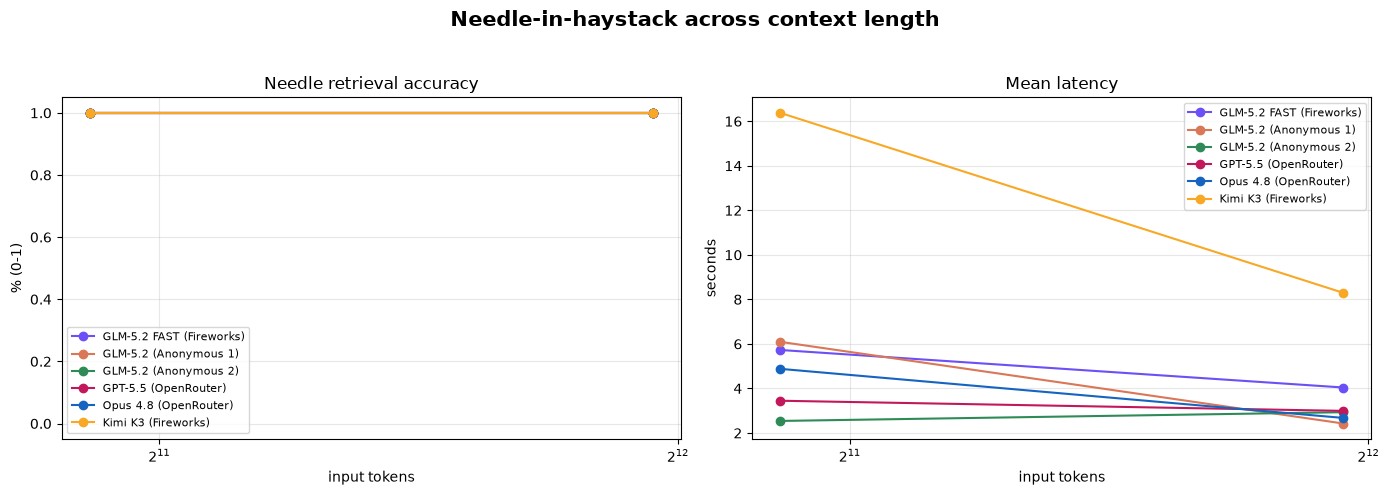

Saved niah_latency_2up.png


In [8]:
import matplotlib.pyplot as plt
from itertools import cycle

names = list(sweep.keys())
_palette = ["#6C4FF6", "#D97757", "#2E8B57", "#C2185B", "#1565C0", "#F9A825"]
colors = {n: c for n, c in zip(names, cycle(_palette))}

# Make two graphs across: left: accuracy, right: mean latency
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Needle-in-haystack across context length", fontsize=15, fontweight="bold")

def line(ax, key, title, ylabel):
    for n in names:
        rows = sweep[n]
        xs = [r["actual_tokens"] for r in rows]
        ys = [r[key] for r in rows]
        ax.plot(xs, ys, "o-", label=n, color=colors[n])
    ax.set_title(title)
    ax.set_xlabel("input tokens")
    ax.set_ylabel(ylabel)
    ax.set_xscale("log", base=2)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

line(axes[0], "accuracy", "Needle retrieval accuracy", "% (0-1)")
axes[0].set_ylim(-0.05, 1.05)
line(axes[1], "mean_latency", "Mean latency", "seconds")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("niah_latency_2up.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved niah_latency_2up.png")

In [7]:
# Tabular dump for the record
for n in names:
    print(f"\n=== {n} ===")
    print(f"{'target':>7} {'actual':>7} {'ok':>5} {'err':>4} {'acc':>5} {'ttft':>7} {'mean':>7} {'p95':>7} {'dec med':>8} {'dec peak':>9} {'pref t/s':>9}")
    for r in sweep[n]:
        _a = r['actual_tokens']
        _a_s = f"{int(_a):>7}" if (_a == _a and _a is not None) else "    nan"
        print(f"{r['target_tokens']:>7} {_a_s} {r['ok']:>3}/{r['n']:<2} {r['errors']:>4} "
              f"{r['accuracy']:>5.0%} {r['mean_ttft']:>7.2f} {r['mean_latency']:>7.2f} {r['p95']:>7.2f} "
              f"{r['median_decode_tok_per_sec']:>8.1f} {r['peak_decode_tok_per_sec']:>9.1f} {r['prefill_tok_per_sec']:>9.1f}")


=== GLM-5.2 FAST (Fireworks) ===
 target  actual    ok  err   acc    ttft    mean     p95  dec med  dec peak  pref t/s
   2048    1866   5/5     0  100%    5.69    5.73   12.84     87.6     597.0     325.8
   4096    3961   5/5     0  100%    4.01    4.04    6.14    134.8     257.8     979.7

=== GLM-5.2 (Anonymous 1) ===
 target  actual    ok  err   acc    ttft    mean     p95  dec med  dec peak  pref t/s
   2048    1866   5/5     0  100%    6.03    6.09   18.55    113.6     674.9     306.3
   4096    3961   5/5     0  100%    2.40    2.43    4.72    121.1     357.6    1632.9

=== GLM-5.2 (Anonymous 2) ===
 target  actual    ok  err   acc    ttft    mean     p95  dec med  dec peak  pref t/s
   2048    1866   5/5     0  100%    2.52    2.54    3.51    842.2    1089.8     734.4
   4096    3961   5/5     0  100%    2.92    2.93    3.81    985.4    3843.4    1350.3

=== GPT-5.5 (OpenRouter) ===
 target  actual    ok  err   acc    ttft    mean     p95  dec med  dec peak  pref t/s
   2048 

### Reading the curves

- **Accuracy dropping at large context** = the model is "lost in the middle" — it stops finding the needle once the haystack gets big enough. A flat 100% line means retrieval holds up across the whole window.
- **Latency growing ~linearly with input tokens** = prefill is doing the expected work with no prefix caching across the (different) haystacks. Sub-linear would suggest caching/early-exit; super-linear suggests quadratic attention or contention.
- **TTFT (time to first token)** tracks prefill cost — it should rise with input length. TTFT dominating total latency at large ctx means the request is **prefill-bound**, not decode-bound.
- **Decode tok/s (excl. prefill)** is the Artificial Analysis [Output Speed](https://artificialanalysis.ai/methodology/performance-benchmarking) metric: `out_tokens / (latency - TTFT)`, measured with streaming so prefill is excluded from the denominator. **Median** = sustained decode speed across reps; **peak** = fastest single rep. Unlike the old `out_tokens / total_latency` number, this stays flat as context grows if the model decodes at a constant rate — a dropping curve means decode itself is slowing under long-context KV pressure, not just that prefill is taking longer.
- **Prefill tok/s roughly flat** = the server ingests context at a steady rate regardless of length. **Dropping** prefill tok/s at large ctx = a serving throughput ceiling (memory bandwidth / KV-cache pressure).
- "Peak" here is **per-request peak decode speed**, not Artificial Analysis's "peak system throughput" (which needs a concurrency load test, a separate experiment). With `NUM_REPS=5` the max is a small sample and somewhat noisy — bump `NUM_REPS` to 10 for a stabler peak (note cost).
- Each rep uses a **different needle** (rotated through `NEEDLE_POOL`) and a **differently shuffled** haystack, so no two reps share a byte prefix — this defeats server-side prefix caching, so every rep pays full prefill and latency numbers aren't artificially low. Actual input-token counts come from the response's `usage.prompt_tokens` (ground truth), which is what's plotted on the x-axis — targets may land slightly off because `litellm.token_counter` is approximate for GLM.

## Inspect example traces

Run the two shortest-context haystacks through the model and print the full responses — so you can eyeball *how* the model answers (and confirm the needle really is in there), not just the aggregates. Cheap; independent of the sweep.